# Miscellaneous

## Setup

Import packages:

In [1]:
import fivecentplots as fcp
import pandas as pd
from pathlib import Path

Read some dummy data for examples:

In [ ]:
df = fcp.get_test_data('fake_data.csv')
df.head()

,Substrate,Target Wavelength,Boost Level,Temperature [C],Die,Voltage,I Set,I [A]
0,Si,450,0.2,25,"(1,1)",0.0,0.0,0.0
1,Si,450,0.2,25,"(1,1)",0.1,0.0,0.0
2,Si,450,0.2,25,"(1,1)",0.2,0.0,0.0
3,Si,450,0.2,25,"(1,1)",0.3,0.0,0.0
4,Si,450,0.2,25,"(1,1)",0.4,0.0,0.0


Optionally set the design theme (skipping here and using default):

In [3]:
#fcp.set_theme('gray')
#fcp.set_theme('white')

## Text boxes

One or more text boxes can be added to any plot via the ``text`` Element class.  

### Single text box

First we consider a single, non-styled text box:

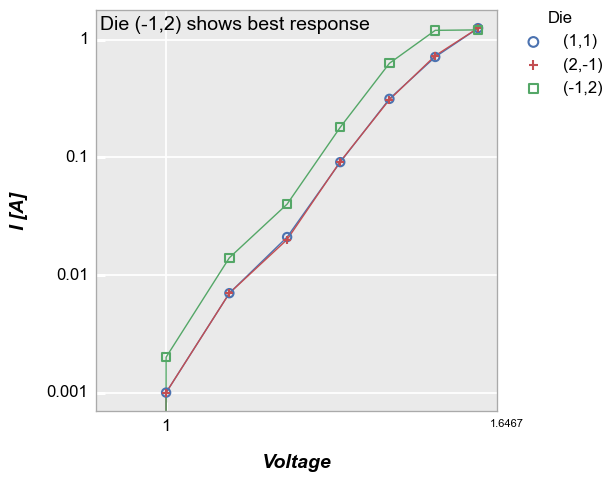

In [ ]:
fcp.plot(df, x='Voltage', y='I [A]', ax_scale='loglog', legend='Die', xmin=0.9,
         filter='Substrate=="Si" & Target Wavelength==450 & Boost Level==0.2 & Temperature [C]==25',
         text='Die (-1,2) shows best response', text_position=[0, 380])

### Single text box with styling

We can enhance the look of the text box by accessing color and font properties in the ``text`` object using keyword arguments or by definition in a custom theme file.  For example, to set the text box fill color, use `text_fill_color`.  The following attributes are defined by default for a text box:

* `edge_color`:  none

* `fill_color`: none

* `font`: sans-serif

* `font_size`: 14

* `font_style`: normal

* `font_weight`: normal

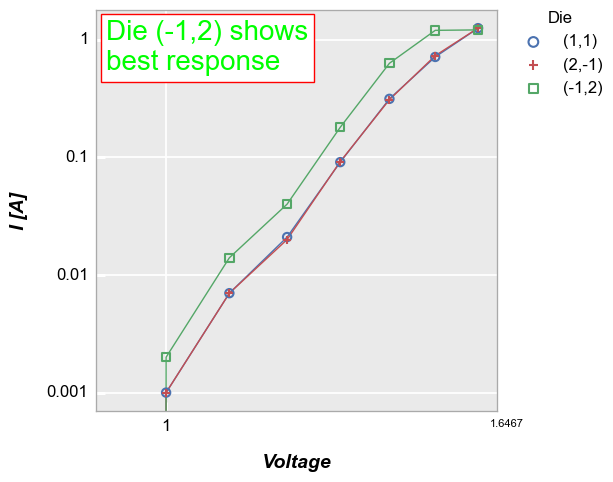

In [ ]:
fcp.plot(df, x='Voltage', y='I [A]', ax_scale='loglog', legend='Die', xmin=0.9,
         filter='Substrate=="Si" & Target Wavelength==450 & Boost Level==0.2 & Temperature [C]==25',
         text='Die (-1,2) shows\nbest response', text_position=[10, 340], text_font_size=20,
         text_edge_color='#FF0000', text_font_color='#00FF00', text_fill_color='#ffffff')

### Multiple text boxes

We can also add multiple text boxes.  Because each styling attribute is a `RepeatedList`, we do not have to explicitly define all attributes for each text box.  The provided list of attributes or defaults is cycled through for each text box.  Notice below that we define a custom position and font size for each text string, but only one `fill_color` and only two `font_color` values.  Because these attributes are `RepeatedList` objects, all elements share the same `fill_color` and the first and third text string share the same `font_color`.

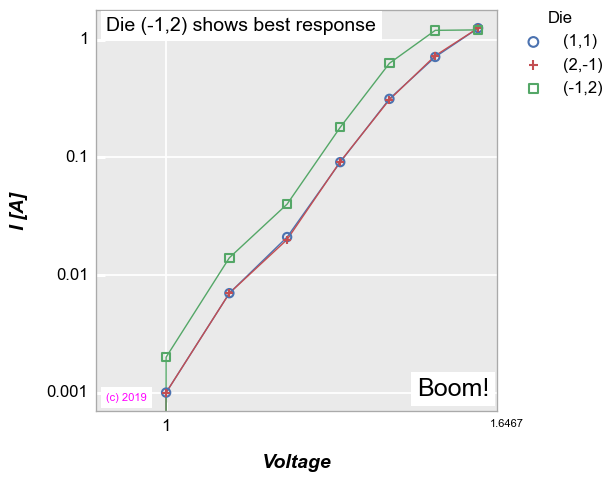

In [ ]:
fcp.plot(df, x='Voltage', y='I [A]', ax_scale='loglog', legend='Die', xmin=0.9,
         filter='Substrate=="Si" & Target Wavelength==450 & Boost Level==0.2 & Temperature [C]==25',
         text=['Die (-1,2) shows best response', '(c) 2019', 'Boom!'],
         text_position=[[10, 379], [10, 10], [320, 15]], text_font_color=['#000000', '#FF00FF'],
         text_font_size=[14, 8, 18], text_fill_color='#FFFFFF')

### Position

#### Coordinate systems

Text box locations can be specified relative to different elements of a given figure:

* **axis**: (0,0) is at the lower left corner of the plot window [default]

* **figure**: (0,0) is at the lower left corner of the entire figure window

* **data**:  position is relative to the actual x,y data coordinates

This value is toggled using the `text_coordinate` keyword.  In the examples below, notice how the `text_position` must change with each coordinate system in order to keep the text box in the same general location.

<b>By "axis" [default]</b>

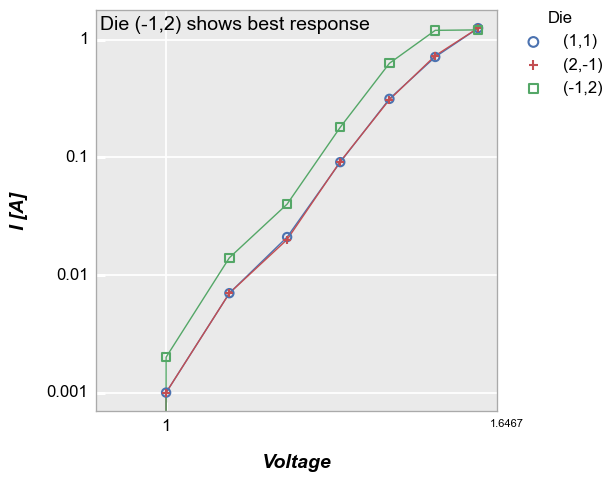

In [ ]:
fcp.plot(df, x='Voltage', y='I [A]', ax_scale='loglog', legend='Die', xmin=0.9,
         filter='Substrate=="Si" & Target Wavelength==450 & Boost Level==0.2 & Temperature [C]==25',
         text='Die (-1,2) shows best response', text_position=[0, 380])

<b>By "figure"</b>

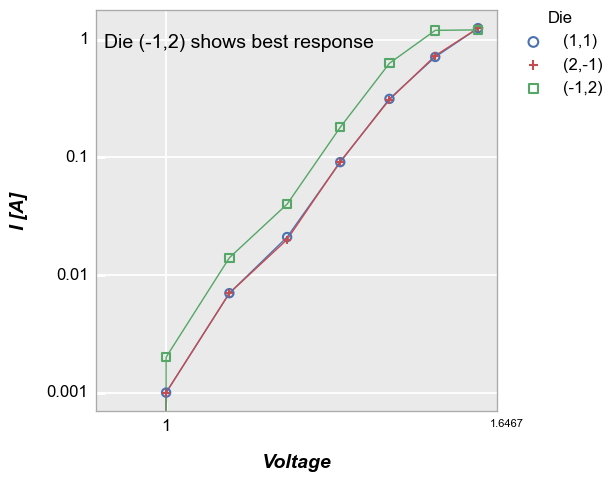

In [ ]:
fcp.plot(df, x='Voltage', y='I [A]', ax_scale='loglog', legend='Die', xmin=0.9,
         filter='Substrate=="Si" & Target Wavelength==450 & Boost Level==0.2 & Temperature [C]==25',
         text='Die (-1,2) shows best response', text_position=[110, 440], text_coordinate='figure')

<b>By "data"</b>

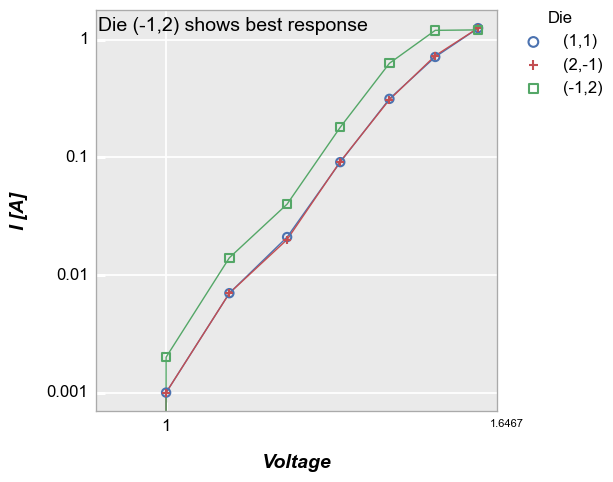

In [ ]:
fcp.plot(df, x='Voltage', y='I [A]', ax_scale='loglog', legend='Die', xmin=0.9,
         filter='Substrate=="Si" & Target Wavelength==450 & Boost Level==0.2 & Temperature [C]==25',
         text='Die (-1,2) shows best response', text_position=[0.903, 1.2], text_coordinate='data')

#### Units

By default, "axis" and "figure" referenced position values are units of pixels.  We can cast these into relative units between 0 and 1 (0 and 100%) of scale using the keyword `text_units`.

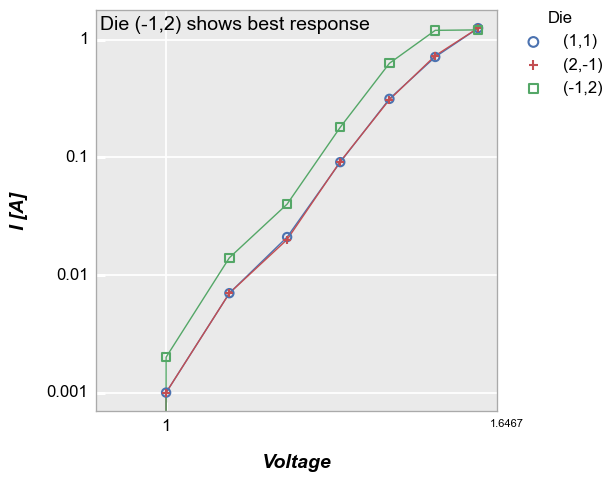

In [ ]:
fcp.plot(df, x='Voltage', y='I [A]', ax_scale='loglog', legend='Die', xmin=0.9,
         filter='Substrate=="Si" & Target Wavelength==450 & Boost Level==0.2 & Temperature [C]==25',
         text='Die (-1,2) shows best response', text_position=[0, 0.95], text_units='relative')

## Axes Transforms

`fivecentplots` provide several options to transform the input data set non-destructively as part of the plot command.  The specific transformation is defined by axis using the kwarg `trans_q` where q = x, x2, y, y2, or z.  Transformation are defined by a string name or, in some cases, a list of a string name and a numeric value:

* `"abs"`:  take the absolute value of the data set
* `"[addition, q]"` or `"[add, q]"`:  add "q" to the data set, where "q" is numeric
* `"[divide, q]"` or "[div, q]":  divide the data set by "q", where "q" is numeric
* `"flip"`:  mirror the axes range horizontal or vertically across its center point
* `"inverse"`:  raise the data set to the power of -1
* `"[multiply, q]"` or `"[mult, q]"`:  multiply the data set by "q", where "q" is numeric
* `"negative"` or `"neg"`:  multiply the data set by -1
* `"nq"`:  compute the normal quantile of the data 
* `"[power, q]"` or `"[pow, q]"`:  raise the data to the power of "q" where "q" is numeric
* `"[subtract, q]"` or `"[sub, q]"`:  subtract "q" from the data set, where "q" is numeric


Consider some examples of transformation on this data set:

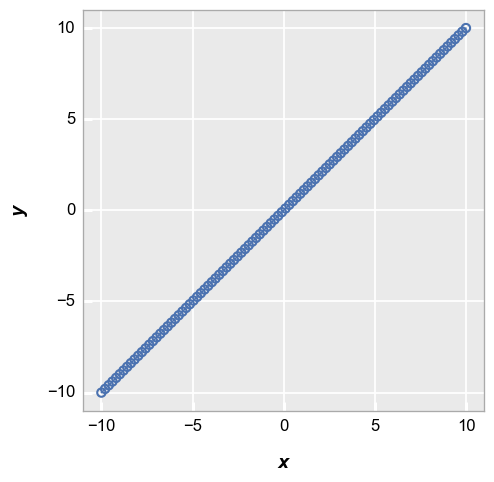

In [5]:
dft = pd.DataFrame({'x': np.linspace(-10, 10, 100), 'y': np.linspace(-10, 10, 100)})
fcp.plot(dft, x='x', y='y')

### abs

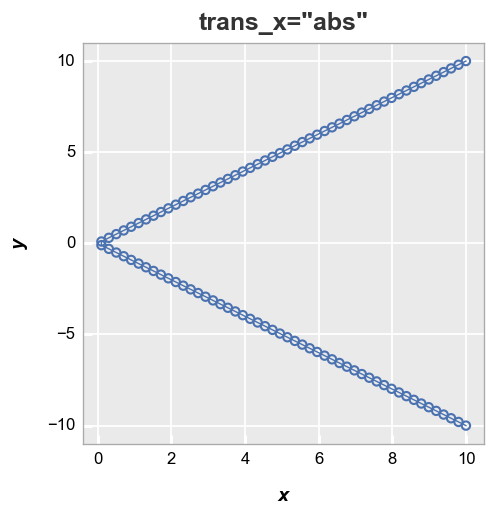

In [7]:
fcp.plot(dft, x='x', y='y', trans_x='abs', title='trans_x="abs"')

### addition

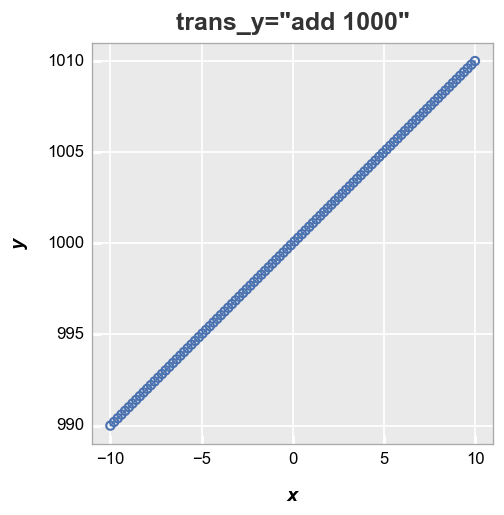

In [10]:
fcp.plot(dft, x='x', y='y', trans_y=['addition', 1e3], title='trans_y="add 1000"')

### flip

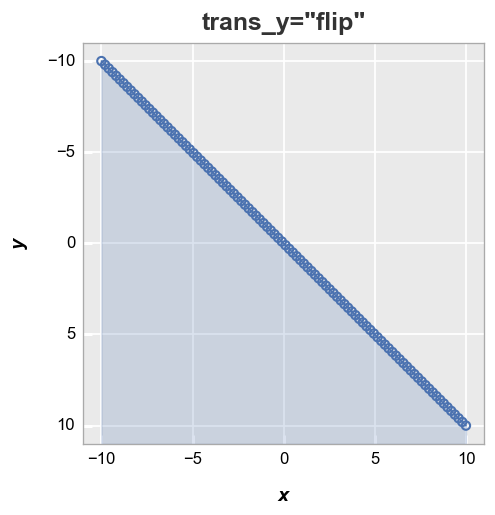

In [20]:
fcp.plot(dft, x='x', y='y', trans_y='flip', title='trans_y="flip"', fill_under=True)

### inverse

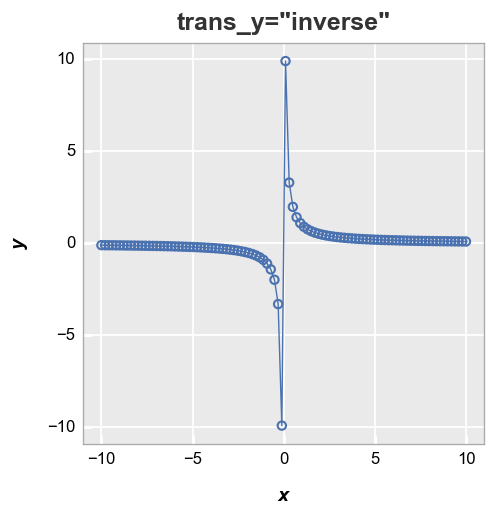

In [12]:
fcp.plot(dft, x='x', y='y', trans_y='inverse', title='trans_y="inverse"')

### nq

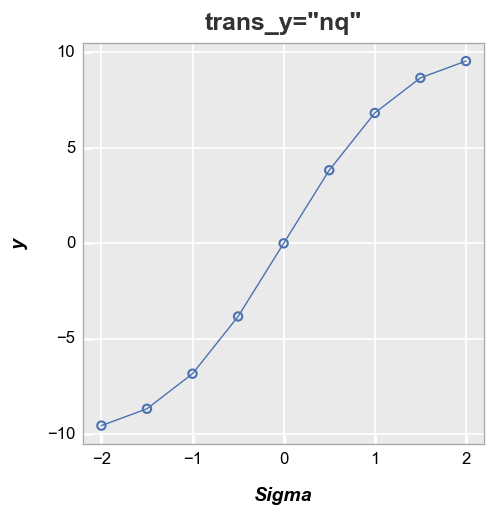

In [18]:
fcp.plot(dft, x='x', y='y', trans_y='nq', title='trans_y="nq"')

### power

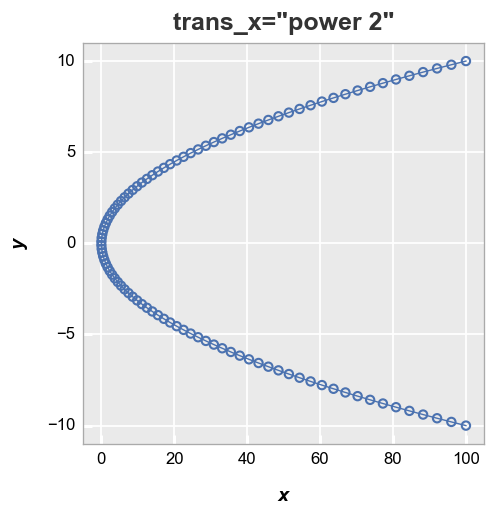

In [19]:
fcp.plot(dft, x='x', y='y', trans_x=['power', 2], title='trans_x="power 2"')

## Background images

Images overlays can be applied to the axes using the `ax_background` or `background` key word and pointing to an image path.  For best results, the axes size should match the resolution of the image.  The background image opacity can be controlled with `ax_background_alpha` or `background_alpha`.

.. note:: This feature is only supported with the `matplotlib` engine

First, load some real population data with latitude and longitude coordinates:

In [21]:
df_map = fcp.get_test_data('real_data_population.csv')
df_map.head()

,City,Latitude,Longitude,Population,Size
0,Tokyo,35.6870,139.7495,37785000.0,25.000000
1,Seoul,37.5667,126.9833,23016000.0,16.007695
2,Moscow,55.7506,37.6175,17332000.0,12.546915
3,Toronto,43.7417,-79.3733,5647656.0,5.432744
4,Philadelphia,40.0077,-75.1339,5696588.0,5.462537


Next, set the path to a background image containing a map of the world:

In [23]:
background_img_path = Path(fcp.__file__).parent / 'test_data/map.png'

Put it together:

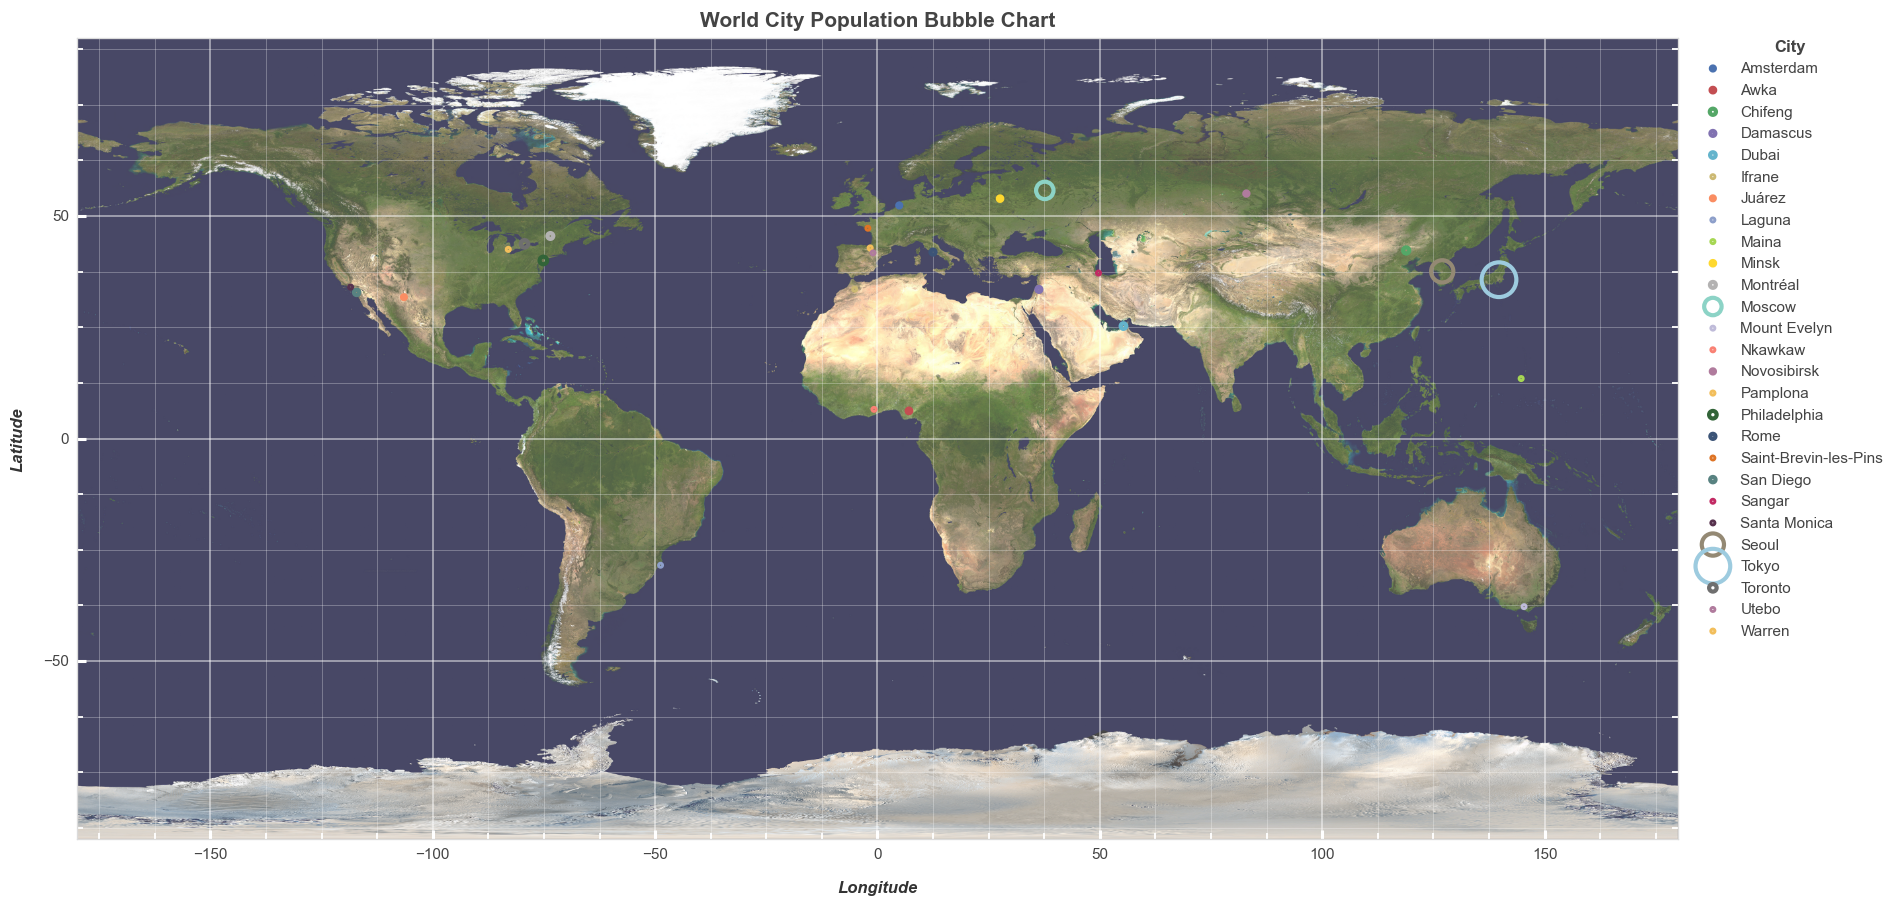

In [27]:
fcp.plot(df_map, y='Latitude', x='Longitude', marker_size='Size', lines=False,
         legend='City', marker_type = 'o', ax_background=background_img_path,
         xmin=-180, xmax=180, ymin=-90, ymax=90, ax_size=[1600, 800], grid_minor=True,
         grid_major_alpha=0.5, grid_minor_alpha=0.4, background_alpha=0.75,
         title='World City Population Bubble Chart', marker_edge_width=3)